The data for this tutorial can be downloaded at: https://drive.google.com/drive/folders/1z5Y2IldWLyiwSaRo2_7cEE3uvAbMZ6dj?usp=sharing

In [1]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import wandb  # Integrated for experiment tracking
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.autograd import Function

In [2]:

# --- 1. Dataset Class ---
class MNISTPickleDataset(Dataset):
    def __init__(self, file_path, mode="Train"):
        with open(file_path, 'rb') as f:
            data = pickle.load(f)

        key_map = {"Train": ("train", "train_labels"),
                   "Val": ("val", "val_labels"),
                   "Test": ("test", "test_labels")}

        img_key, lbl_key = key_map.get(mode, key_map["Test"])
        self.images = data[img_key]
        self.labels = data[lbl_key]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])
        if len(img.shape) == 2:
            img = np.stack([img] * 3, axis=-1)
        return self.transform(img), label


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 50, kernel_size=5), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.label_predictor = nn.Sequential(
            nn.Linear(50 * 4 * 4, 100), nn.ReLU(), nn.Linear(100, 10)
        )

    def forward(self, x, alpha=1.0):
        features = self.feature_extractor(x).view(-1, 50 * 4 * 4)
        return self.label_predictor(features)

def validate(model, loader, device, criterion):
    model.eval()
    loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            class_out = model(imgs)
            loss += criterion(class_out, labels).item()
            _, pred = torch.max(class_out, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return loss / len(loader), 100 * correct / total

# --- 4. Main Training & WandB Logging ---
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

    # Initialize WandB
    wandb.init(
        project="cnn-mnist-m",
        config={
            "learning_rate": 0.01,
            "architecture": "DANN",
            "dataset": "MNIST to MNIST-M",
            "epochs": 20,
            "batch_size": 64
        }
    )

    model = CNN().to(device)
    wandb.watch(model, log_freq=100) # Tracks gradients in wandb

    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    epochs = 20
    for epoch in range(epochs):
        model.train()
        len_loader = len(src_train)

        for i, (s_img, s_lbl) in enumerate(src_train):

            optimizer.zero_grad()
            s_img, s_lbl = s_img.to(device), s_lbl.to(device)

            # Forward Source
            s_cls = model(s_img)
            loss_s_cls = criterion(s_cls, s_lbl)

            total_loss = loss_s_cls
            total_loss.backward()
            optimizer.step()

            # Log step-level metrics
            if i % 10 == 0:
                wandb.log({
                    "batch_total_loss": total_loss.item(),
                })

        # Epoch Validation
        v_loss, v_acc = validate(model, src_val, device, criterion)
        wandb.log({
            "epoch": epoch + 1,
            "val_loss": v_loss,
            "val_accuracy": v_acc
        })

        print(f"Epoch {epoch+1:02d} | Val Loss: {v_loss:.3f} | Val Acc: {v_acc:.2f}%")

    # Final Test Set Evaluation
    test_loss, test_acc = validate(model, tgt_test, device, criterion)
    test_loss2, test_acc2 = validate(model, src_test, device, criterion)

    wandb.log({"test_loss": test_loss, "test_accuracy": test_acc})
    print(f"\n--- Final Test Accuracy - target domain: {test_acc:.2f}% ---")
    print(f"\n--- Final Test Accuracy - source domain: {test_acc2:.2f}% ---")

    wandb.finish()

In [4]:
# Paths
mnist_path = "/content/mnist_data.pkl"
mnist_m_path = "/content/mnistm_data.pkl"

# Loaders
src_train = DataLoader(MNISTPickleDataset(mnist_path, "Train"), batch_size=64, shuffle=True, drop_last=True)
src_val = DataLoader(MNISTPickleDataset(mnist_path, "Val"), batch_size=64, shuffle=False)
src_test = DataLoader(MNISTPickleDataset(mnist_path, "Test"), batch_size=64, shuffle=False)
tgt_test = DataLoader(MNISTPickleDataset(mnist_m_path, "Test"), batch_size=64, shuffle=False)


/tmp/ipykernel_1449/3507818756.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


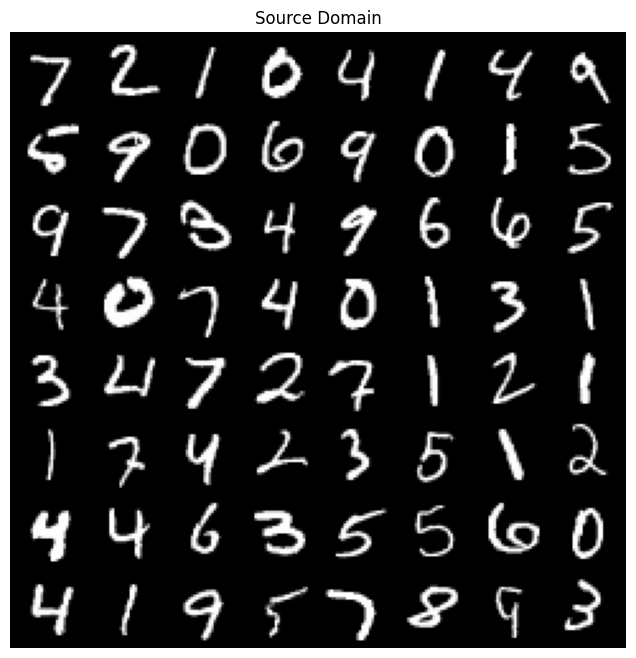

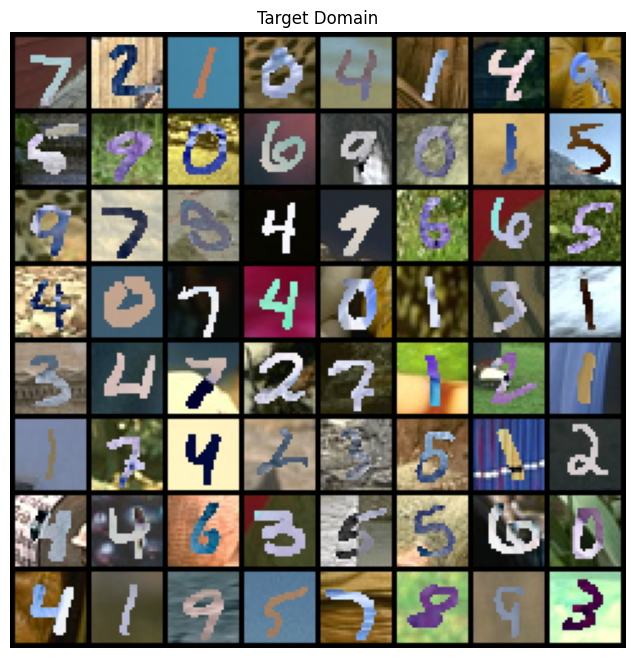

In [5]:
from torchvision.utils import make_grid

src_sample = next(iter(src_test))
tgt_sample = next(iter(tgt_test))

grid_tensor = make_grid(src_sample[0], nrow=8, padding=2, normalize=True)

# 3. Convert from Tensor (C, H, W) to Numpy (H, W, C) for Matplotlib
grid_numpy = grid_tensor.permute(1, 2, 0).cpu().numpy()

# 4. Plot
plt.figure(figsize=(12, 8))
plt.imshow(grid_numpy)
plt.axis('off')
plt.title(f"Source Domain")
plt.show()

grid_tensor2 = make_grid(tgt_sample[0], nrow=8, padding=2, normalize=True)

# 3. Convert from Tensor (C, H, W) to Numpy (H, W, C) for Matplotlib
grid_numpy2 = grid_tensor2.permute(1, 2, 0).cpu().numpy()

# 4. Plot
plt.figure(figsize=(12, 8))
plt.imshow(grid_numpy2)
plt.axis('off')
plt.title(f"Target Domain")
plt.show()



In [6]:
train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gsanjaykumar-1509 (gsanjaykumar-1509-university-of-calgary-in-alberta) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 01 | Val Loss: 0.060 | Val Acc: 98.08%
Epoch 02 | Val Loss: 0.050 | Val Acc: 98.46%
Epoch 03 | Val Loss: 0.034 | Val Acc: 98.92%
Epoch 04 | Val Loss: 0.029 | Val Acc: 99.14%
Epoch 05 | Val Loss: 0.024 | Val Acc: 99.23%
Epoch 06 | Val Loss: 0.029 | Val Acc: 99.12%
Epoch 07 | Val Loss: 0.025 | Val Acc: 99.32%
Epoch 08 | Val Loss: 0.026 | Val Acc: 99.21%
Epoch 09 | Val Loss: 0.028 | Val Acc: 99.23%
Epoch 10 | Val Loss: 0.033 | Val Acc: 99.17%
Epoch 11 | Val Loss: 0.030 | Val Acc: 99.20%
Epoch 12 | Val Loss: 0.034 | Val Acc: 99.20%
Epoch 13 | Val Loss: 0.029 | Val Acc: 99.32%
Epoch 14 | Val Loss: 0.041 | Val Acc: 99.08%
Epoch 15 | Val Loss: 0.031 | Val Acc: 99.38%
Epoch 16 | Val Loss: 0.031 | Val Acc: 99.39%
Epoch 17 | Val Loss: 0.031 | Val Acc: 99.41%
Epoch 18 | Val Loss: 0.034 | Val Acc: 99.35%
Epoch 19 | Val Loss: 0.032 | Val Acc: 99.42%
Epoch 20 | Val Loss: 0.031 | Val Acc: 99.39%

--- Final Test Accuracy - target domain: 61.50% ---

--- Final Test Accuracy - source domain: 99.32

batch_total_loss,█▁▁▂▁▁▂▂▁▆▁▁▂▁▁▂▃▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_accuracy,▁
test_loss,▁
val_accuracy,▁▃▅▇▇▆▇▇▇▇▇▇▇▆██████
val_loss,█▆▃▂▁▂▁▁▂▃▂▃▂▄▂▂▂▃▃▂
batch_total_loss,2e-05
epoch,20
test_accuracy,61.5
test_loss,1.59321
val_accuracy,99.39167
